In [2]:
import os
import sys
import yaml
import torch
import numpy as np
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split

# =====================================================================
# 0. CONFIGURATION & CUSTOM IMPORTS
# =====================================================================
helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from SimpleMAF import SimpleMAF 

dataset_path = "Final_Dataset_ML"
model_path = "Models_Extrapolation_ML"
config_path = "configs"  
os.makedirs(model_path, exist_ok=True)

device = torch.device("cuda" if False else "cpu")
print(f"Using device: {device}")

# Define the features to generate and the conditional/context variables
# Adjust these lists based on your specific Normalizing Flow architecture
features_to_generate = [
    'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj'
]

context_vars = [
    'met_recalc_pt', 'ht'
]

regions_to_load = ["CR1L", "CR1L1B", "CR2L", "CR0L"]

# --- TRAINING MODE TOGGLE ---
TRAIN_MODE = "combined"  # Set to "separate" (1 model per CR) or "combined" (1 model for all CRs)
N_ENSEMBLES = 1          
TARGET_DATASET = "DATA"  # Usually NF generation targets 'DATA' or 'MC' in the CRs

# =====================================================================
# 1. LOAD AND ORGANIZE DATASETS BASED ON MODE
# =====================================================================
training_tasks = {} # Will hold format: {"RunName": df_target}

print(f"\nPreparing data in '{TRAIN_MODE}' mode targeting {TARGET_DATASET}...")

if TRAIN_MODE == "separate":
    for region in regions_to_load:
        train_path = f"{dataset_path}/{region}/{TARGET_DATASET}_{region}_train.parquet"
        test_path  = f"{dataset_path}/{region}/{TARGET_DATASET}_{region}_test.parquet"
        try:
            df_train = pl.read_parquet(train_path).to_pandas()
            df_test = pl.read_parquet(test_path).to_pandas()
            training_tasks[region] = (df_train, df_test)
            print(f"Loaded train/test splits for {region}...")
        except Exception as e:
            print(f"Skipping {region} (Files not found or error loading: {e})")

elif TRAIN_MODE == "combined":
    run_name = "Combined_CRs"
    train_path = f"{dataset_path}/{run_name}/{TARGET_DATASET}_{run_name}_train.parquet"
    test_path  = f"{dataset_path}/{run_name}/{TARGET_DATASET}_{run_name}_test.parquet"
    try:
        df_train = pl.read_parquet(train_path).to_pandas()
        df_test = pl.read_parquet(test_path).to_pandas()
        training_tasks[run_name] = (df_train, df_test)
        print(f"Loaded {run_name} pre-split datasets...")
        print(df_train.head())
    except Exception as e:
        print(f"Failed to load combined datasets. Error: {e}")
        print("Did you run the Classifier script in 'combined' mode first?")
        sys.exit()
else:
    print("Invalid TRAIN_MODE. Choose 'separate' or 'combined'.")
    sys.exit()

# =====================================================================
# 2. MAIN TRAINING LOOP OVER CONFIGURED TASKS
# =====================================================================

# Load parameters from the configuration file
with open(f"{config_path}/generate_physics.yml", 'r') as stream:
    params_gen = yaml.safe_load(stream)

# 'run_name' will be "CR1L", "CR0L", etc., OR "Combined_CRs"
for run_name, (data_train, data_test) in training_tasks.items():
    print(f"\n{'='*70}")
    print(f" 🚀 PROCESSING GENERATOR: {run_name}")
    print(f"{'='*70}")
    
    # Notice: train_test_split is completely removed here!
    print(f"Data Loaded -> Train: {len(data_train)} | Test: {len(data_test)}")

    # --- A. Extract Features and Context for PyTorch ---
    x_train = data_train[features_to_generate].values
    c_train = data_train[context_vars].values

    x_test = data_test[features_to_generate].values
    c_test = data_test[context_vars].values

    # --- C. Ensemble Training ---
    for i in range(N_ENSEMBLES):
        print(f"\n--- Training Generator Ensemble {i+1}/{N_ENSEMBLES} for {run_name} ---")
        
        current_seed = 42 + i*7
        model_name = f"generate_{run_name}_ens{i}"
        
        # Initialize the Normalizing Flow Model
        MAF = SimpleMAF(
            num_features=len(features_to_generate), 
            num_context=len(context_vars), 
            num_hidden_features=params_gen["n_hidden_features"], 
            num_layers=params_gen["n_layers"], 
            learning_rate=float(params_gen["learning_rate"]),
            device=device
        )
        
        # Train the model
        MAF.train(
            data=x_train, 
            cond=c_train, 
            batch_size=params_gen["batch_size"], 
            n_epochs=params_gen["n_epochs"], 
            outdir=model_path, 
            save_model=True, 
            model_name=model_name,
            seed=current_seed,
            early_stop=True
        )



    print(f"✅ Finished Transfer Learning/Training for {run_name} Generator!")

print("\n🎉 Generative training phase complete!")

Using device: cpu

Preparing data in 'combined' mode targeting DATA...
Loaded Combined_CRs pre-split datasets...
   met_recalc_pt  met_recalc_phi        ht       mjj  ljet1_tau21  \
0      -1.520432        0.270110 -2.423058 -2.407404     0.334391   
1      -1.683546        0.614970 -2.434849 -2.252114     0.199633   
2      -1.679614        1.316346 -2.438912 -2.459021    -1.273243   
3      -1.169937       -1.666954 -2.368119 -2.396576     0.849528   
4      -1.510660       -0.544596 -2.400581 -2.376458    -0.582775   

   ljet1_tau32  ljet2_tau21  ljet2_tau32  
0     0.536041    -0.146898     1.345369  
1     1.447305     1.359976     1.336073  
2     1.234552     0.188479    -0.837654  
3     1.579775    -0.941918     2.220068  
4     1.566330     1.150626     1.480373  

 🚀 PROCESSING GENERATOR: Combined_CRs
Data Loaded -> Train: 3843414 | Test: 960854

--- Training Generator Ensemble 1/1 for Combined_CRs ---


100%|==========| 20/20 [1:13:05<00:00, 219.30s/it]

✅ Finished Transfer Learning/Training for Combined_CRs Generator!

🎉 Generative training phase complete!


Using device: cuda
 🔬 INITIATING GENERATOR CLOSURE TESTS (MODE 4)
Mode 4: Combined plot using the COMBINED Generative model.

Plotting Combined_CRs (Using Combined Model)...
Metrics for ljet1_tau21 in Combined_CRs:
  Generated -> chi2/ndf: 28.84/14 (p=0.0110) | Norm W1: 0.0165
------------------------------------------------------------


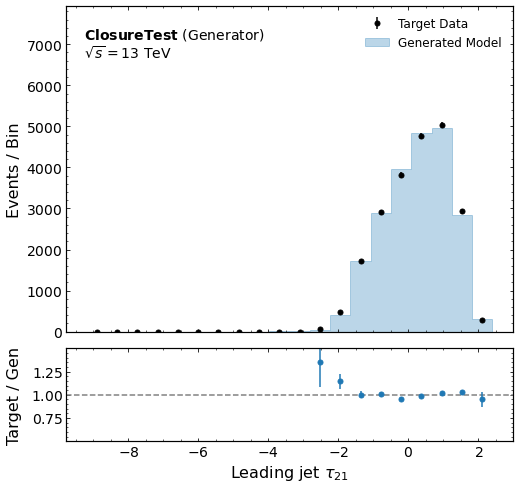

Metrics for ljet1_tau32 in Combined_CRs:
  Generated -> chi2/ndf: 155.01/19 (p=0.0000) | Norm W1: 0.0190
------------------------------------------------------------


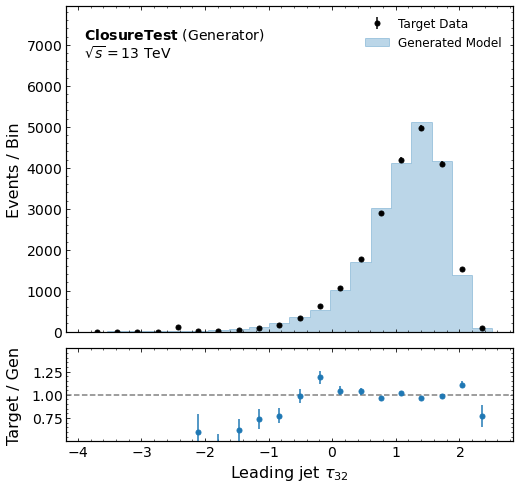

Metrics for ljet2_tau21 in Combined_CRs:
  Generated -> chi2/ndf: 58.84/19 (p=0.0000) | Norm W1: 0.0222
------------------------------------------------------------


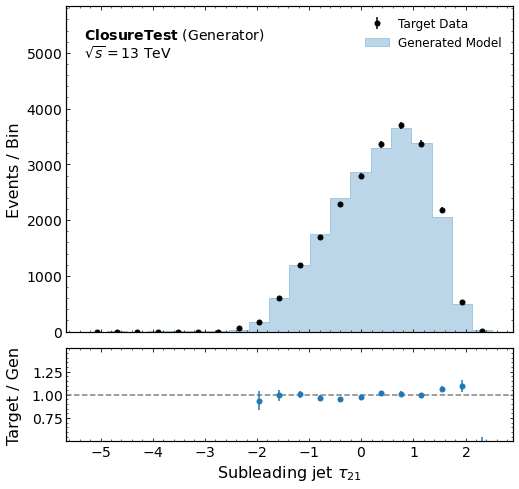

Metrics for ljet2_tau32 in Combined_CRs:
  Generated -> chi2/ndf: 138.09/19 (p=0.0000) | Norm W1: 0.0156
------------------------------------------------------------


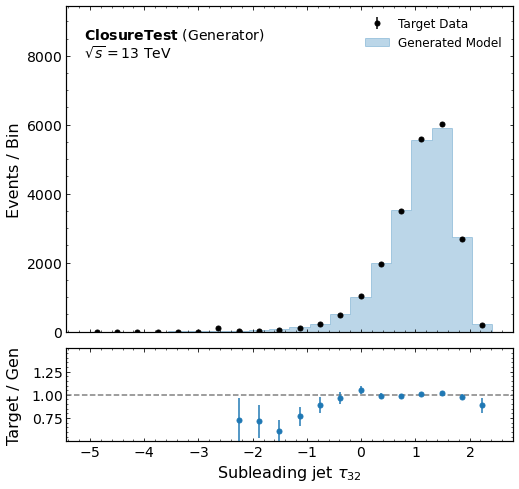

Metrics for mjj in Combined_CRs:
  Generated -> chi2/ndf: 45.40/19 (p=0.0006) | Norm W1: 0.0198
------------------------------------------------------------


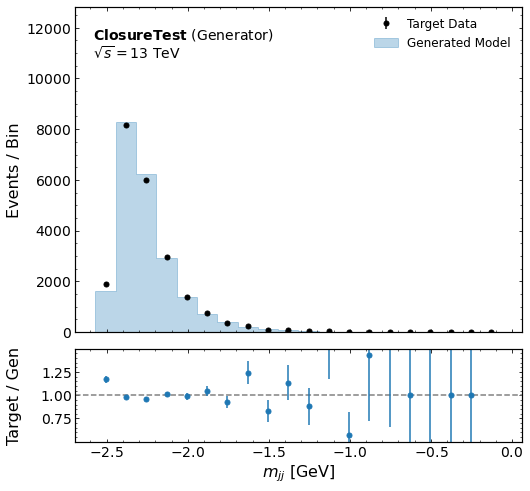

In [3]:
import os
import sys
import torch
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from scipy.stats import chi2 as chi2_stat
from scipy.stats import wasserstein_distance

# Ensure PyTorch can find your SimpleMAF class definition
helpers_path = os.path.abspath('/home/aegis/Titan1/NRAD/data/model_scripts')
if helpers_path not in sys.path:
    sys.path.insert(0, helpers_path)
from SimpleMAF import SimpleMAF

# =====================================================================
# 1. CONFIGURATION & MODE SELECTION
# =====================================================================
dataset_path = "Final_Dataset_ATLAS"
model_path = "Models_Extrapolation_ATLAS"
plot_dir = "Closure_Plots_Generate"
os.makedirs(plot_dir, exist_ok=True)

regions = ["CR1L", "CR1L1B", "CR2L", "CR0L"]

# Define what the NF generates vs what it conditions on
features_to_generate = [
    'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj'
]

context_vars = [
    'met_recalc_pt', 'ht'
]

TARGET_DATASET = "DATA" # Should match what you trained the NF on (e.g., 'DATA' or 'MC')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------------------
# SELECT YOUR CLOSURE TEST MODE (1, 2, 3, or 4)
# ---------------------------------------------------------------------
EVALUATION_MODE = 4

# Mode 1: Per-region plot using respective trained generator
# Mode 2: Per-region plot using the COMBINED trained generator
# Mode 3: Combined plot using events generated from separate regions
# Mode 4: Combined plot using the COMBINED trained generator

# =====================================================================
# 2. HELPER FUNCTIONS
# =====================================================================

def generate_synthetic_data(model, df_target_pd, features, contexts):
    """Passes context through the Normalizing Flow to generate synthetic features."""
    # Extract Context
    c_test = df_target_pd[contexts].values
    
    # Generate 1 sample per context row
    # SimpleMAF sample() handles device transfer and numpy conversion internally
    samples = model.sample(num_samples=1, cond=c_test)
    
    # Reconstruct a DataFrame with the generated features
    df_gen_pd = pd.DataFrame(samples, columns=features)
    
    # Append the context variables back in case we want to plot them
    for c in contexts:
        df_gen_pd[c] = df_target_pd[c].values
        
    # Inherit the exact weights from the target dataset for 1-to-1 comparison
    weight_col = "final_weight" if "final_weight" in df_target_pd.columns else ("raw_weights" if "raw_weights" in df_target_pd.columns else None)
    if weight_col:
        df_gen_pd['weight'] = df_target_pd[weight_col].values
    else:
        df_gen_pd['weight'] = 1.0
        
    return df_gen_pd

def plot_generative_closure(region_name: str, df_target: pl.DataFrame, df_gen: pl.DataFrame, feature: str, force_log: bool = False):
    """
    Creates a HEP closure plot comparing Target Data vs Generated Data.
    Main distribution on top, Ratio on the bottom.
    """
    
    # Thesis/Publication styling settings
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 12,
        'lines.linewidth': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'axes.formatter.use_mathtext': True,
        'axes.linewidth': 1.2
    })
    
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }
    
    log_variables = ['ht', 'met_recalc_pt', 'met']
    use_log = force_log or any(log_var in feature.lower() for log_var in log_variables)
    
    # Extract arrays
    target_arr = df_target.get_column(feature).drop_nulls().to_numpy()
    gen_arr = df_gen.get_column(feature).drop_nulls().to_numpy()
    
    if len(target_arr) == 0 and len(gen_arr) == 0:
        print(f"Skipping {feature} - No valid data.")
        return
        
    # Extract Weights
    weight_col = "final_weight" if "final_weight" in df_target.columns else ("raw_weights" if "raw_weights" in df_target.columns else None)
    target_weights = df_target.get_column(weight_col).to_numpy() if weight_col else np.ones_like(target_arr)
    gen_weights = df_gen.get_column("weight").to_numpy()
    
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
    
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    # Dynamic binning spanning both distributions
    combined_arr = np.concatenate([target_arr, gen_arr])
    bins = np.histogram_bin_edges(combined_arr, bins=20)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # --- 1. MAIN PANEL ---
    # Generated Model (Blue Filled)
    counts_gen, _ = np.histogram(gen_arr, bins=bins, weights=gen_weights)
    sumw2_gen, _ = np.histogram(gen_arr, bins=bins, weights=gen_weights**2)
    ax_main.hist(gen_arr, bins=bins, weights=gen_weights, histtype='stepfilled', 
                 color='#1f78b4', alpha=0.3, edgecolor='#1f78b4', label='Generated Model')
    
    # Target Data (Black Points)
    counts_target, _ = np.histogram(target_arr, bins=bins, weights=target_weights)
    sumw2_target, _ = np.histogram(target_arr, bins=bins, weights=target_weights**2)
    target_errors = np.sqrt(sumw2_target) # Proper error for weighted data
    
    ax_main.errorbar(bin_centers, counts_target, yerr=target_errors, 
                     fmt='ko', label='Target Data', zorder=10, capsize=0, markersize=5)
    
    # --- METRICS CALCULATION ---
    std_target = np.std(target_arr) if len(target_arr) > 0 else 1.0
    c_gen_clean = np.clip(counts_gen, 0, None)
    c_target_clean = np.clip(counts_target, 0, None)
    
    w1_ml = wasserstein_distance(bin_centers, bin_centers, 
                                 u_weights=c_target_clean, v_weights=c_gen_clean) / std_target

    def get_chi2_pval(c_target, c_gen, s2_target, s2_gen):
        mask = (c_target > 0) | (c_gen > 0)
        tot_var = s2_target[mask] + s2_gen[mask]
        valid = tot_var > 0
        chi2_val = np.sum((c_target[mask][valid] - c_gen[mask][valid])**2 / tot_var[valid])
        ndf = np.sum(valid) - 1 
        if ndf < 1: ndf = 1
        p_val = chi2_stat.sf(chi2_val, ndf)
        return chi2_val, ndf, p_val

    chi2_ml, ndf_ml, p_ml = get_chi2_pval(counts_target, counts_gen, sumw2_target, sumw2_gen)

    print(f"Metrics for {feature} in {region_name}:")
    print(f"  Generated -> chi2/ndf: {chi2_ml:.2f}/{ndf_ml} (p={p_ml:.4f}) | Norm W1: {w1_ml:.4f}")
    print("-" * 60)

    # --- DYNAMIC SCALING ---
    max_target = np.max(counts_target) + np.max(target_errors) if len(counts_target) > 0 else 0
    max_gen = np.max(counts_gen) if len(counts_gen) > 0 else 0
    y_max = max(max_target, max_gen)
    
    if use_log:
        ax_main.set_yscale('log')
        ax_main.set_ylim(0.1, y_max * 100)
    else:
        ax_main.set_ylim(0, y_max * 1.55)
        ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
    ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_main.set_ylabel("Events / Bin")
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    textstr = r"$\mathbf{Closure Test}$ (Generator)" +"\n"+ r"$\sqrt{s} = 13$ TeV"
    ax_main.text(0.04, 0.94, textstr, transform=ax_main.transAxes, fontsize=14, verticalalignment='top')
                 
    # Custom Legend Formatting
    handles, loc_labels = ax_main.get_legend_handles_labels()
    if "Target Data" in loc_labels:
        idx = loc_labels.index("Target Data")
        handles.insert(0, handles.pop(idx))
        loc_labels.insert(0, loc_labels.pop(idx))
    ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=1)
    
    # --- 2. RATIO PANEL ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_ml = counts_target / counts_gen
        
        # Error propagation for ratio (Target / Generated)
        rel_err_target = np.where(counts_target > 0, target_errors / counts_target, 0)
        rel_err_gen = np.where(counts_gen > 0, np.sqrt(sumw2_gen) / counts_gen, 0)
        ratio_ml_err = ratio_ml * np.sqrt(rel_err_target**2 + rel_err_gen**2)
        
        ratio_ml = np.where(counts_gen > 0, ratio_ml, np.nan)
        ratio_ml_err = np.where(counts_gen > 0, ratio_ml_err, np.nan)

    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
    
    ax_ratio.errorbar(bin_centers, ratio_ml, yerr=ratio_ml_err, fmt='o', 
                      color='#1f78b4', capsize=0, markersize=5)
    
    x_label = pretty_labels.get(feature, feature)
    
    ax_ratio.set_xlabel(x_label)
    ax_ratio.set_ylabel("Target / Gen")
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.set_yticks([0.75, 1.0, 1.25])
    
    ax_ratio.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig.align_ylabels((ax_main, ax_ratio))
    
    # --- 3. SAVE AND CLOSE ---
    filename_region = f"_{region_name.replace(' ', '_')}" if region_name else ""
    save_name = f"{plot_dir}/gen_closure_{feature}{filename_region}.pdf"
    
    # plt.savefig(save_name, bbox_inches='tight', format='pdf')
    plt.show() # Uncomment to show interatively
    plt.close(fig)

# =====================================================================
# 3. EXECUTION LOGIC BASED ON MODE
# =====================================================================
print("="*60)
print(f" 🔬 INITIATING GENERATOR CLOSURE TESTS (MODE {EVALUATION_MODE})")
print("="*60)

if EVALUATION_MODE == 1:
    print("Mode 1: Per-region closure using separate Generative models.")
    for region in regions:
        try:
            # Load Target Test Data
            df_target_pd = pl.read_parquet(f"{dataset_path}/{region}_Gen/{TARGET_DATASET}_{region}_test.parquet").to_pandas()
            
            # Load specific model
            model_file = os.path.join(model_path, f"generate_{region}_ens0.pt")
            model = torch.load(model_file, map_location=device, weights_only=False)
            model.to(device)
            
            # Generate Synthetic Data
            df_gen_pd = generate_synthetic_data(model, df_target_pd, features_to_generate, context_vars)
            
            df_target = pl.from_pandas(df_target_pd)
            df_gen = pl.from_pandas(df_gen_pd)
            
            print(f"\nPlotting {region}...")
            for feature in features_to_generate:
                plot_generative_closure(region, df_target, df_gen, feature)
        except Exception as e:
            print(f"Skipping {region}: {e}")

elif EVALUATION_MODE == 2:
    print("Mode 2: Per-region closure using the COMBINED Generative model.")
    try:
        model_file = os.path.join(model_path, "generate_Combined_CRs_ens0.pt")
        combined_model = torch.load(model_file, map_location=device, weights_only=False)
        combined_model.to(device)
        print(f"Successfully loaded Combined Model.")
    except Exception as e:
        print(f"Failed to load Combined Model. Error: {e}")
        sys.exit()

    for region in regions:
        try:
            df_target_pd = pl.read_parquet(f"{dataset_path}/{region}_Gen/{TARGET_DATASET}_{region}_test.parquet").to_pandas()
            
            # Evaluate using Combined Model
            df_gen_pd = generate_synthetic_data(combined_model, df_target_pd, features_to_generate, context_vars)
            
            df_target = pl.from_pandas(df_target_pd)
            df_gen = pl.from_pandas(df_gen_pd)
            
            print(f"\nPlotting {region} (Generated via Combined Model)...")
            for feature in features_to_generate:
                plot_generative_closure(f"{region}_via_CombinedModel", df_target, df_gen, feature)
        except Exception as e:
            print(f"Skipping {region}: {e}")

elif EVALUATION_MODE == 3:
    print("Mode 3: Combined plot using events generated from separate models.")
    target_dfs = []
    gen_dfs = []
    
    for region in regions:
        try:
            df_target_pd = pl.read_parquet(f"{dataset_path}/{region}_Gen/{TARGET_DATASET}_{region}_test.parquet").to_pandas()
            
            model_file = os.path.join(model_path, f"generate_{region}_ens0.pt")
            model = torch.load(model_file, map_location=device, weights_only=False)
            model.to(device)
            
            df_gen_pd = generate_synthetic_data(model, df_target_pd, features_to_generate, context_vars)
            
            target_dfs.append(pl.from_pandas(df_target_pd))
            gen_dfs.append(pl.from_pandas(df_gen_pd))
        except Exception as e:
            print(f"Skipping {region} from combination: {e}")
            
    if target_dfs and gen_dfs:
        df_target_all = pl.concat(target_dfs)
        df_gen_all = pl.concat(gen_dfs)
        print("\nPlotting Combined Dataset (Using Separate Models)...")
        for feature in features_to_generate:
            plot_generative_closure("All_Regions_SeparateModels", df_target_all, df_gen_all, feature)
    else:
        print("No datasets found to combine.")

elif EVALUATION_MODE == 4:
    print("Mode 4: Combined plot using the COMBINED Generative model.")
    run_name = "Combined_CRs"
    try:
        model_file = os.path.join(model_path, f"generate_{run_name}_ens0.pt")
        combined_model = torch.load(model_file, map_location=device, weights_only=False)
        combined_model.to(device)
        
        df_target_pd = pl.read_parquet(f"{dataset_path}/{run_name}/{TARGET_DATASET}_{run_name}_test.parquet").to_pandas()
        
        df_gen_pd = generate_synthetic_data(combined_model, df_target_pd, features_to_generate, context_vars)
        
        df_target = pl.from_pandas(df_target_pd)
        df_gen = pl.from_pandas(df_gen_pd)
        
        print(f"\nPlotting {run_name} (Using Combined Model)...")
        for feature in features_to_generate:
            plot_generative_closure(run_name, df_target, df_gen, feature)
    except Exception as e:
        print(f"Failed to load datasets/models for Mode 4. Error: {e}")

else:
    print("Invalid EVALUATION_MODE. Please select 1, 2, 3, or 4.")